In [50]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


In [51]:
# path_output = '/Users/gwen29360/Desktop/POSTDOC/LEGOS/SWOT/figure_composite_paper/'
path_input = '../data/'
path_output = '../figures/'

In [52]:
theta = np.linspace(0, 2*np.pi, 100)
x_circle = np.cos(theta)
y_circle = np.sin(theta)

x_circle_small = np.cos(theta)/2.5
y_circle_small = np.sin(theta)/2.5


arrow_length = 0.8  # Adjust length as needed
x_start = 0
y_start = 0
theta_rot = 0
x_end = x_start + arrow_length * np.cos(theta_rot*(+1))
y_end = y_start + arrow_length * np.sin(theta_rot*(+1))

props1 = dict(boxstyle='round', facecolor='w', alpha=1)
n_quiver = 15


def plot_composite(ax, compo_2D, vmin, vmax, cmap0):
    p1 = ax.pcolormesh(compo_2D.x, compo_2D.y,  compo_2D, vmin = vmin, vmax = vmax, cmap = cmap0)
    ax.plot(x_circle, y_circle, color = 'k', linewidth = 2)
    ax.plot(x_circle, y_circle, color = 'w', linewidth = .5, linestyle = '--')
    ax.set_xticks([-1, -.4, 0, .4, 1], ['-2.5$R_{max}$', '-$R_{max}$', '0', '$R_{max}$', '2.5$R_{max}$'], rotation = 90)
    ax.set_yticks([-1, -.4, 0, .4, 1], ['-2.5$R_{max}$', '-$R_{max}$', '0', '$R_{max}$', '2.5$R_{max}$'])

    
    ax.plot(x_circle_small, y_circle_small, color = 'k', linewidth = 2)
    ax.plot(x_circle_small, y_circle_small, color = 'w', linewidth = .5)
    ax.plot(x_circle, y_circle, color = 'k', linewidth = 2)
    ax.plot(x_circle, y_circle, color = 'w', linewidth = .5, linestyle = '--')

    return p1

In [53]:

###########
# --- GS2
###########
ds_GS = xr.open_dataset(path_input + 'composite_GS.nc')

KE_GS2_cyclonic = ds_GS.KE_swot_cyc
KE_GS2_DUACS_cyclonic = ds_GS.KE_swot_cyc_DUACS

KE_GS2_anticyclonic = ds_GS.KE_swot_anticyc
KE_GS2_DUACS_anticyclonic = ds_GS.KE_swot_anticyc_DUACS


###########
# --- AGULHAS
###########

ds_AGULHAS = xr.open_dataset(path_input + 'composite_AGULHAS.nc')

KE_AGULHAS_cyclonic = ds_AGULHAS.KE_swot_cyc
KE_AGULHAS_DUACS_cyclonic = ds_AGULHAS.KE_swot_cyc_DUACS

KE_AGULHAS_anticyclonic = ds_AGULHAS.KE_swot_anticyc
KE_AGULHAS_DUACS_anticyclonic = ds_AGULHAS.KE_swot_anticyc_DUACS

###########
# --- CCS
###########

ds_CCS = xr.open_dataset(path_input + 'composite_CCS.nc')


KE_CCS_cyclonic = ds_CCS.KE_swot_cyc
KE_CCS_DUACS_cyclonic = ds_CCS.KE_swot_cyc_DUACS

KE_CCS_anticyclonic = ds_CCS.KE_swot_anticyc
KE_CCS_DUACS_anticyclonic = ds_CCS.KE_swot_anticyc_DUACS




###########
# --- ACC-1
###########


ds_ACC1 = xr.open_dataset(path_input + 'composite_ACC1.nc')


KE_ACC1_cyclonic = ds_ACC1.KE_swot_cyc
KE_ACC1_DUACS_cyclonic = ds_ACC1.KE_swot_cyc_DUACS

KE_ACC1_anticyclonic = ds_ACC1.KE_swot_anticyc
KE_ACC1_DUACS_anticyclonic = ds_ACC1.KE_swot_anticyc_DUACS


###########
# --- ACC-2
###########

ds_ACC2 = xr.open_dataset(path_input + 'composite_ACC2.nc')


KE_ACC2_cyclonic = ds_ACC2.KE_swot_cyc
KE_ACC2_DUACS_cyclonic = ds_ACC2.KE_swot_cyc_DUACS

KE_ACC2_anticyclonic = ds_ACC2.KE_swot_anticyc
KE_ACC2_DUACS_anticyclonic = ds_ACC2.KE_swot_anticyc_DUACS


###########
# --- MED
###########


ds_MED = xr.open_dataset(path_input + 'composite_MED.nc')


KE_MED_cyclonic = ds_MED.KE_swot_cyc
KE_MED_DUACS_cyclonic = ds_MED.KE_swot_cyc_DUACS

KE_MED_anticyclonic = ds_MED.KE_swot_anticyc
KE_MED_DUACS_anticyclonic = ds_MED.KE_swot_anticyc_DUACS



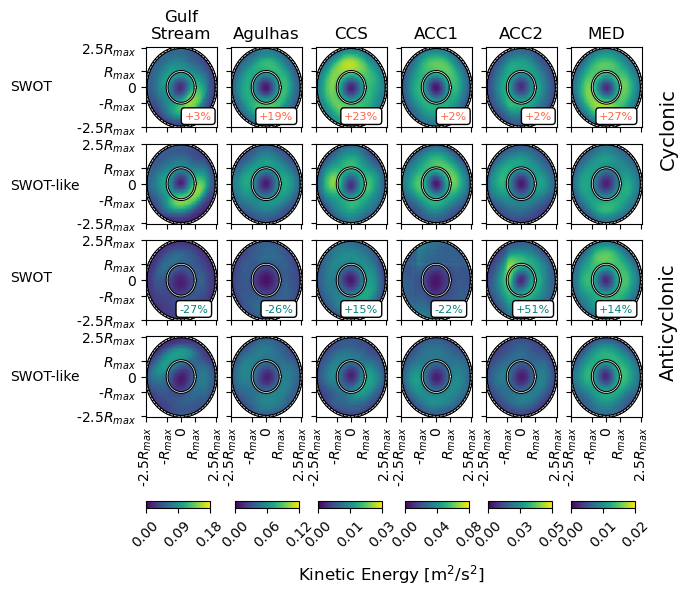

In [54]:
fig, axes = plt.subplots(ncols = 6, nrows = 4, sharex = True, sharey = True)
vmin = 0
vmax = .1
nb_quiver = 33
ax = axes[0][0]
ax.set_title('Gulf\nStream')
vmin = 0
vmax = .18
p1 = plot_composite(ax, KE_GS2_cyclonic, vmin, vmax, 'viridis')
ax.text(.1, -.8, '+3%', color = 'tomato', bbox = props1, fontsize = 8)

ax = axes[1][0]
_ = plot_composite(ax, KE_GS2_DUACS_cyclonic, vmin, vmax, 'viridis')

ax = axes[2][0]
_ = plot_composite(ax, KE_GS2_anticyclonic, vmin, vmax, 'viridis')
ax.text(-.05, -.8, '-27%', color = 'teal', bbox = props1, fontsize = 8)

ax = axes[3][0]
_ = plot_composite(ax, KE_GS2_DUACS_anticyclonic, vmin, vmax, 'viridis')

cax = fig.add_axes([.125, -.08, .1, 0.015])
cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

cbar.ax.tick_params(rotation=45)

ax = axes[0][1]
vmin = 0
vmax = 0.12
ax.set_title('Agulhas')
p1 = plot_composite(ax, KE_AGULHAS_cyclonic, vmin, vmax, 'viridis')
ax.text(-.2, -.8, '+19%', color = 'tomato', bbox = props1, fontsize = 8)

ax = axes[1][1]
_ = plot_composite(ax, KE_AGULHAS_DUACS_cyclonic, vmin, vmax, 'viridis')


ax = axes[2][1]
_ = plot_composite(ax, KE_AGULHAS_anticyclonic, vmin, vmax, 'viridis')
ax.text(-.05, -.8, '-26%', color = 'teal', bbox = props1, fontsize = 8)

ax = axes[3][1]
_ = plot_composite(ax, KE_AGULHAS_DUACS_anticyclonic, vmin, vmax, 'viridis')


cax = fig.add_axes([.265, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)


ax = axes[0][2]
vmin = 0.0
vmax = 0.025
ax.set_title('CCS')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1= plot_composite(ax, KE_CCS_cyclonic, vmin, vmax, 'viridis')
ax.text(-.2, -.8, '+23%', color = 'tomato', bbox = props1, fontsize = 8)

ax = axes[1][2]
_ = plot_composite(ax, KE_CCS_DUACS_cyclonic, vmin, vmax, 'viridis')

ax = axes[2][2]
_ = plot_composite(ax, KE_CCS_anticyclonic, vmin, vmax, 'viridis')
ax.text(-.2, -.8, '+15%', color = 'teal', bbox = props1, fontsize = 8)

ax = axes[3][2]
_ = plot_composite(ax, KE_CCS_DUACS_anticyclonic, vmin, vmax, 'viridis')

cax = fig.add_axes([.395, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)



ax = axes[0][3]
vmin = 0.0
vmax = 0.08
ax.set_title('ACC1')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1 = plot_composite(ax, KE_ACC1_cyclonic, vmin, vmax, 'viridis')
ax.text(.1, -.8, '+2%', color = 'tomato', bbox = props1, fontsize = 8)

ax = axes[1][3]
_ = plot_composite(ax, KE_ACC1_DUACS_cyclonic, vmin, vmax, 'viridis')


ax = axes[2][3]
_ = plot_composite(ax, KE_ACC1_anticyclonic, vmin, vmax, 'viridis')
ax.text(-.05, -.8, '-22%', color = 'teal', bbox = props1, fontsize = 8)

ax = axes[3][3]
_ = plot_composite(ax, KE_ACC1_DUACS_anticyclonic, vmin, vmax, 'viridis')


cax = fig.add_axes([.53, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)


ax = axes[0][4]
vmin = 0.0
vmax = 0.05
ax.set_title('ACC2')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1 = plot_composite(ax, KE_ACC2_cyclonic,  vmin, vmax,  'viridis')
ax.text(.1, -.8, '+2%', color = 'tomato', bbox = props1, fontsize = 8)


ax = axes[1][4]
_ = plot_composite(ax, KE_ACC2_DUACS_cyclonic,  vmin, vmax,  'viridis')


ax = axes[2][4]
_ = plot_composite(ax, KE_ACC2_anticyclonic,  vmin, vmax,  'viridis')
ax.text(-.15, -.8, '+51%', color = 'teal', bbox = props1, fontsize = 8)


ax = axes[3][4]
_ = plot_composite(ax, KE_ACC2_DUACS_anticyclonic, vmin, vmax,  'viridis')



cax = fig.add_axes([.66, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])

cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
cbar.ax.tick_params(rotation=45)


ax = axes[0][5]
vmin = 0.0
vmax = 0.02
ax.set_title('MED')
# ax.pcolormesh(ds_GS2_DUACS_cyclonic.x, ds_GS2_DUACS_cyclonic.y, uspeed_GS2_cyclonic, vmin = 0, vmax = .4)
p1 = plot_composite(ax, KE_MED_cyclonic,  vmin, vmax,  'viridis')
ax.text(-.2, -.8, '+27%', color = 'tomato', bbox = props1, fontsize = 8)


ax = axes[1][5]
_ = plot_composite(ax, KE_MED_DUACS_cyclonic,  vmin, vmax,  'viridis')


ax = axes[2][5]
_ = plot_composite(ax, KE_MED_anticyclonic,  vmin, vmax,  'viridis')
ax.text(-.2, -.8, '+14%', color = 'teal', bbox = props1, fontsize = 8)


ax = axes[3][5]
_ = plot_composite(ax, KE_MED_DUACS_anticyclonic, vmin, vmax,  'viridis')



cax = fig.add_axes([.79, -.08, .1, 0.015])

cbar = plt.colorbar(p1, cax = cax, orientation = 'horizontal', ticks = [vmin, (vmin+vmax)/2, vmax])
cbar.ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# cbar.ax.set_xticklabels(clevs1[::1] rotation=90)
cbar.ax.tick_params(rotation=45)
# cbar.ax.set_title('Current speed [m/s]')
ax.text(-17, -.1, 'SWOT-like')
ax.text(-17, 2.4, 'SWOT')
ax.text(-17, 4.7, 'SWOT-like')
ax.text(-17, 7.2, 'SWOT')
ax.text(1.5, 0, 'Anticyclonic', rotation = 90, fontsize = 14)
ax.text(1.5, 5.3, 'Cyclonic', rotation = 90, fontsize = 14)
ax.text(-8.8, -5.1, 'Kinetic Energy [m$^{2}$/s$^{2}$]', fontsize = 12)
plt.savefig(path_output + 'Fig2.png', dpi = 300, bbox_inches = 'tight')
